In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.6 MB/s eta 0:00:00



image 1/1 /content/sample_data/street.jpg: 384x640 1 person, 7 cars, 2 traffic lights, 161.8ms
Speed: 3.5ms preprocess, 161.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
car: 0.83 at [381, 237, 428, 270]
car: 0.82 at [755, 231, 825, 311]
car: 0.78 at [696, 227, 779, 299]
car: 0.78 at [458, 235, 503, 272]
car: 0.71 at [263, 230, 310, 274]
traffic light: 0.64 at [116, 87, 136, 124]
car: 0.55 at [599, 245, 648, 274]
person: 0.54 at [346, 228, 372, 278]
traffic light: 0.53 at [291, 94, 306, 127]
car: 0.51 at [312, 235, 354, 271]


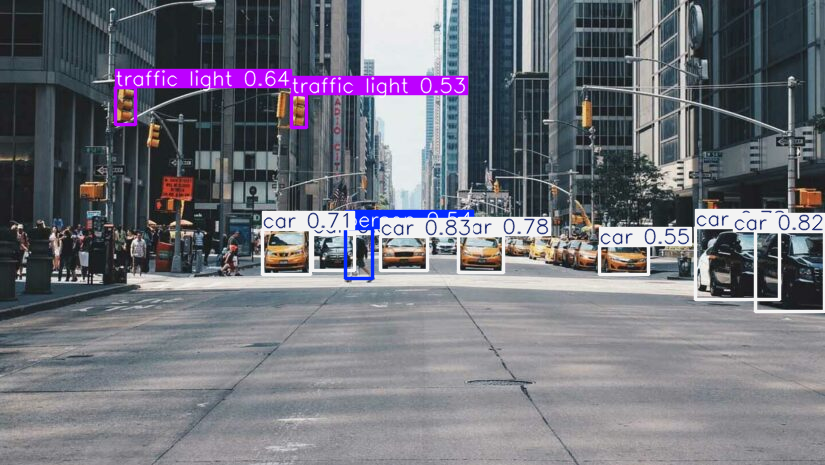

In [ ]:
# Install library (run once in Colab)
!pip install ultralytics

# Import libraries
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load pretrained YOLOv8 Nano model
model = YOLO('yolov8n.pt')

# Run detection on image
results = model('/content/sample_data/street.jpg', conf=0.5)

# Process detection results
for result in results:
    boxes = result.boxes

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]

        print(f'{cls_name}: {conf:.2f} at [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]')

# Show image with bounding boxes
annotated = results[0].plot()
cv2_imshow(annotated)